# Reddit Research: Taoism

## 4. Sentiment Analysis with RoBERTa

This notebook analyzes the emotional tone and sentiment of Reddit comments related to Taoism. Building on previous clustering and rhetorical analysis, we now apply two transformer-based models to assess the affective landscape of the discourse. First, we use a fine-tuned RoBERTa model to assign each comment a sentiment score and sentiment label (positive, neutral, or negative). Then, we use the GoEmotions model developed by Google to classify each comment into one or more emotion categories, such as joy, anger, surprise, or sadness. These annotations allow us to investigate how different rhetorical patterns (identity, community, authority, etc.) correlate with emotional expression, and to visualize how affect is distributed across themes in the Taoist subreddit. This approach will help uncover how emotion and sentiment shape religious discourse in digital environments.

In [1]:
# Load core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Hugging Face tools
from transformers import pipeline

# Set display options for Pandas
pd.set_option("display.max_colwidth", 200)

# Define model names for later use
roberta_sentiment_model = "cardiffnlp/twitter-roberta-base-sentiment"
goemotions_model = "bhadresh-savani/distilbert-base-uncased-emotion"

print("Libraries loaded and models defined.")


Libraries loaded and models defined.


As before, the first thing we have to do is loading the.csv file containing our comments. Then, we will initializes the RoBERTa sentiment pipeline using Hugging Face’s pre-trained model. After that, we apply the sentiment model to each comment’s raw text (body) and extract both a sentiment label (positive/neutral/negative) and a confidence score. These are added as new columns to the DataFrame: sentiment_label and sentiment_score.

In [2]:
# Load the labeled dataset
comments_df = pd.read_csv("../data/taoism_comments_labeled_rhetoric.csv")

In [7]:
from tqdm.auto import tqdm
from transformers import pipeline

# Initialize sentiment analysis pipeline with truncation
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=roberta_sentiment_model,
    tokenizer=roberta_sentiment_model,
    truncation=True,
    max_length=512,
)

# Prepare data
texts = comments_df["body"].tolist()
batch_size = 32
num_batches = (len(texts) + batch_size - 1) // batch_size  # ceiling division

# Apply sentiment analysis in batches with progress bar
sentiment_labels = []
sentiment_scores = []

for i in tqdm(range(num_batches), desc="Running sentiment model", unit="batch"):
    batch_texts = texts[i * batch_size : (i + 1) * batch_size]
    outputs = sentiment_pipeline(batch_texts)
    
    for output in outputs:
        sentiment_labels.append(output["label"])
        sentiment_scores.append(output["score"])

# Add results to the DataFrame
comments_df["sentiment_label"] = sentiment_labels
comments_df["sentiment_score"] = sentiment_scores

print("Sentiment analysis completed and added to DataFrame.")

Device set to use cpu


Running sentiment model:   0%|          | 0/62 [00:00<?, ?batch/s]

Sentiment analysis completed and added to DataFrame.


With the sentiment analysis completed, we will rename the labels to give them a more descriptive name.

In [9]:
label_map = {
    "LABEL_0": "negative",
    "LABEL_1": "neutral",
    "LABEL_2": "positive"
}

# Apply mapping to sentiment_label column
comments_df["sentiment_label"] = comments_df["sentiment_label"].map(label_map)

In [11]:
# Count of sentiment labels
print("Sentiment label distribution:")
print(comments_df["sentiment_label"].value_counts())

# Show example rows
print("\nSample labeled comments:")
comments_df[["body", "sentiment_label", "sentiment_score"]].sample(10, random_state=42)

Sentiment label distribution:
sentiment_label
neutral     1070
positive     476
negative     435
Name: count, dtype: int64

Sample labeled comments:


,body,sentiment_label,sentiment_score
582,"https://safety4sea.com/cm-enso-circle-letting-go-of-the-mind/\n\n""￼\n\nEnso Circle: Letting go of the mind\n\nby The Editorial Team\n\n \n\n August 29, 2023\n\n￼\n\nCredit: Shutterstock\n\nAccordi...",neutral,0.639626
1958,What is the “natural way?” \n\nHumans have been farming for thousands of years and in the process depleting the soil and causing desertification. Our destruction of the environment has sped up wit...,negative,0.453804
1244,Zi ping bazi which I teach still follows RST but I agree all other modern practitioners are doing it wrong. The 24 seasons are an auxiliary energy to the true lunar and solar time in Luxe Zi Ping ...,negative,0.577652
1094,"If I can make choices that exist outside of God, then something exists outside of God and God isn't everything.\n\n\nAlso, if God is everything, then he is also a ""She"".",neutral,0.683813
916,"The meeting between Laozi and Confucius is a myth, and their ideas didn't clash.",neutral,0.714728
70,??? Perhaps you should read less into a question. Also no Taoist would be this flippant,negative,0.786923
429,"Tao is the Way of Power or the Power of the Way. Sometimes you stray from the Way, if you didn't, it wouldn't be the Way. The Tao that can be spoken of, is not the true Tao. Words and thoughts are...",neutral,0.596077
777,"Enlightenment means all kinds of things to different groups of people, so above I just said it was marked either by being a higher state of being (like enlightened people described in stories) or ...",neutral,0.514305
1621,Wayne Dyer has some great interpretations of the Dao.,positive,0.862031
1668,No idea what is going on here,negative,0.535733


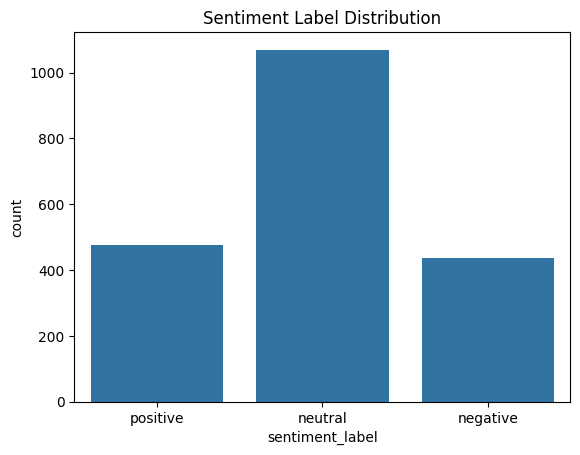

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=comments_df, x="sentiment_label", order=["positive", "neutral", "negative"])
plt.title("Sentiment Label Distribution")
plt.show()

The results show that the majority of comments were classified as neutral (1,070), with fewer comments classified as positive (476) and negative (435). To visualize this distribution, we generated a bar chart that clearly reflects this predominance of neutral sentiment within the dataset.

### Emotion Classification with GoEmotions

Now we will classify the emotions expressed in each Reddit comment using the GoEmotions model. This model, based on DistilBERT, was trained on over 58,000 Reddit comments and can assign up to 28 possible emotions (e.g., joy, anger, admiration, confusion, relief, etc.). Each comment may contain multiple emotions, or sometimes none if it’s neutral.

In [20]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch
from tqdm.auto import tqdm

# Load GoEmotions model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("bhadresh-savani/distilbert-base-uncased-emotion")
model = AutoModelForSequenceClassification.from_pretrained("bhadresh-savani/distilbert-base-uncased-emotion")

# Initialize pipeline
emotion_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True,
    truncation=True
)

# Define emotion label list (ensure correct order)
emotion_labels = [model.config.id2label[i] for i in range(len(model.config.id2label))]

# Function to extract emotion(s) above a confidence threshold
def extract_emotions_batch(texts, threshold=0.3):
    batch_outputs = emotion_pipeline(texts)
    results = []
    for scores in batch_outputs:
        filtered = [d for d in scores if d["score"] >= threshold]
        sorted_emotions = sorted(filtered, key=lambda x: x["score"], reverse=True)
        labels = [d["label"] for d in sorted_emotions]
        top = labels[0] if labels else None
        results.append((labels, top))
    return results

# Prepare data
texts = comments_df["body"].tolist()
batch_size = 32
num_batches = (len(texts) + batch_size - 1) // batch_size

# Initialize results lists
emotion_labels_list = []
top_emotions_list = []

# Process in batches with progress bar
for i in tqdm(range(num_batches), desc="Running GoEmotions model", unit="batch"):
    batch_texts = texts[i * batch_size : (i + 1) * batch_size]
    batch_results = extract_emotions_batch(batch_texts)
    
    # Unpack batch results
    for labels, top in batch_results:
        emotion_labels_list.append(labels)
        top_emotions_list.append(top)

# Save to DataFrame
comments_df["emotion_labels"] = emotion_labels_list
comments_df["top_emotion"] = top_emotions_list

print("Emotion classification complete.")

Device set to use cpu
C:\Users\bacep\Desktop\Research\Contemporary Esotericism\reddit-taoism-analysis\.venv\lib\site-packages\transformers\pipelines\text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


Running GoEmotions model:   0%|          | 0/62 [00:00<?, ?batch/s]

Emotion classification complete.


Now we will inspect the emotion classification output. We will observe the most common top-level emotions assigned across all comments, and a few example comments with their corresponding emotion list and top emotion.

In [23]:
# Count top emotion ocurrences
print("Top emotion distribution:")
print(comments_df["top_emotion"].value_counts())

# Show sample labeled comments
print("\nSample labeled comments with emotions:")
comments_df[["body", "emotion_labels", 'top_emotion']].sample(20, random_state=42)

Top emotion distribution:
top_emotion
joy         1243
anger        441
sadness      174
fear          80
surprise      27
love          16
Name: count, dtype: int64

Sample labeled comments with emotions:


,body,emotion_labels,top_emotion
582,"https://safety4sea.com/cm-enso-circle-letting-go-of-the-mind/\n\n""￼\n\nEnso Circle: Letting go of the mind\n\nby The Editorial Team\n\n \n\n August 29, 2023\n\n￼\n\nCredit: Shutterstock\n\nAccordi...",[joy],joy
1958,What is the “natural way?” \n\nHumans have been farming for thousands of years and in the process depleting the soil and causing desertification. Our destruction of the environment has sped up wit...,[joy],joy
1244,Zi ping bazi which I teach still follows RST but I agree all other modern practitioners are doing it wrong. The 24 seasons are an auxiliary energy to the true lunar and solar time in Luxe Zi Ping ...,[anger],anger
1094,"If I can make choices that exist outside of God, then something exists outside of God and God isn't everything.\n\n\nAlso, if God is everything, then he is also a ""She"".","[joy, anger]",joy
916,"The meeting between Laozi and Confucius is a myth, and their ideas didn't clash.",[anger],anger
70,??? Perhaps you should read less into a question. Also no Taoist would be this flippant,[anger],anger
429,"Tao is the Way of Power or the Power of the Way. Sometimes you stray from the Way, if you didn't, it wouldn't be the Way. The Tao that can be spoken of, is not the true Tao. Words and thoughts are...",[sadness],sadness
777,"Enlightenment means all kinds of things to different groups of people, so above I just said it was marked either by being a higher state of being (like enlightened people described in stories) or ...",[joy],joy
1621,Wayne Dyer has some great interpretations of the Dao.,[joy],joy
1668,No idea what is going on here,[anger],anger


Now we’ll visualize how emotions are distributed across the five rhetorical categories (Identity, Community, Network, Authority, Blurring Online/Offline). This will help us answer questions like:

Which rhetorical frame contains the most joyful or angry comments?

Is “Authority” more emotionally polarized than “Community”?

Does “Blurring Online/Offline” carry a more introspective emotional tone?

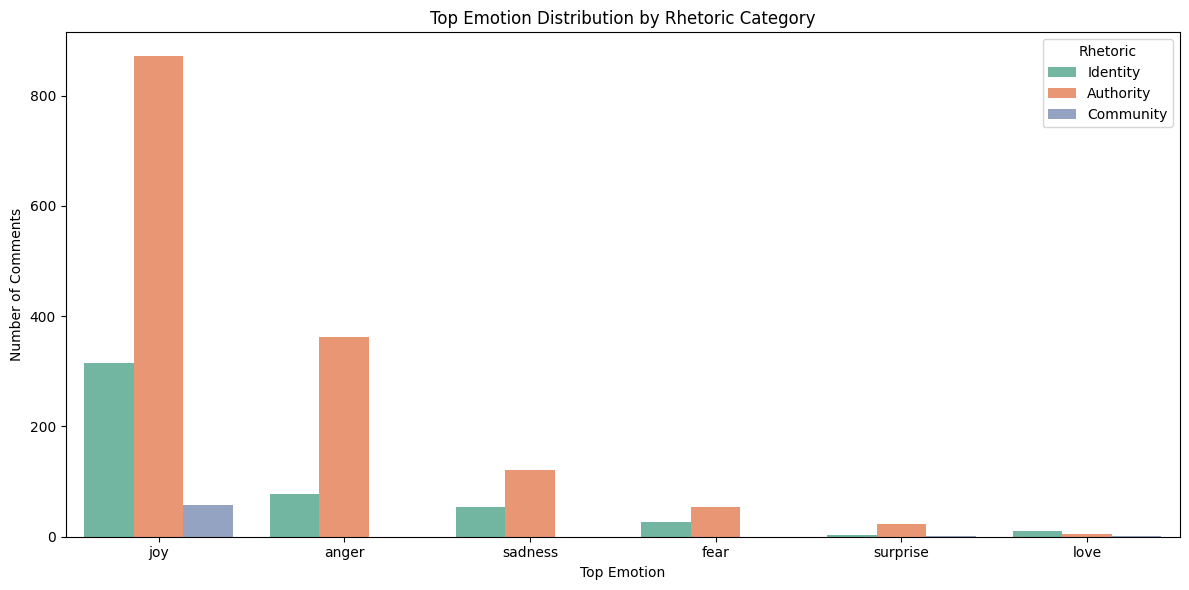

In [25]:
plt.figure(figsize=(12, 6))

# Only include comments where a top emotion was detected
filtered_df = comments_df[comments_df["top_emotion"].notna()]

# Plot emotion counts per rhetoric category
sns.countplot(
    data=filtered_df,
    x="top_emotion",
    hue="rhetoric",
    order=filtered_df["top_emotion"].value_counts().index,
    palette="Set2"
)

plt.title("Top Emotion Distribution by Rhetoric Category")
plt.xlabel("Top Emotion")
plt.ylabel("Number of Comments")
plt.legend(title="Rhetoric")
plt.tight_layout()
plt.show()


In this section, we classified the emotions in each comment using the GoEmotions model. The most common top emotion was joy (1,243 comments), followed by anger (441), sadness (174), fear (80), surprise (27), and love (16). When visualizing this distribution across rhetoric categories, we observed that joy is especially prevalent in Identity and Authority rhetoric, while anger is more frequent in Authority. Community rhetoric had lower representation overall.

Now we will calculate a joy-to-anger ratio (or "joy/anger index") across your dataset, grouped by rhetoric category. This helps you see which rhetorical functions are associated with more uplifting or contentious affect.

A high joy/anger ratio suggests emotionally positive engagement (e.g., spiritual growth or community building). A lower ratio might indicate tension, critique, or defensiveness (often found in Authority rhetoric).

We’ll plot a bar chart showing the joy/anger index per rhetoric category.

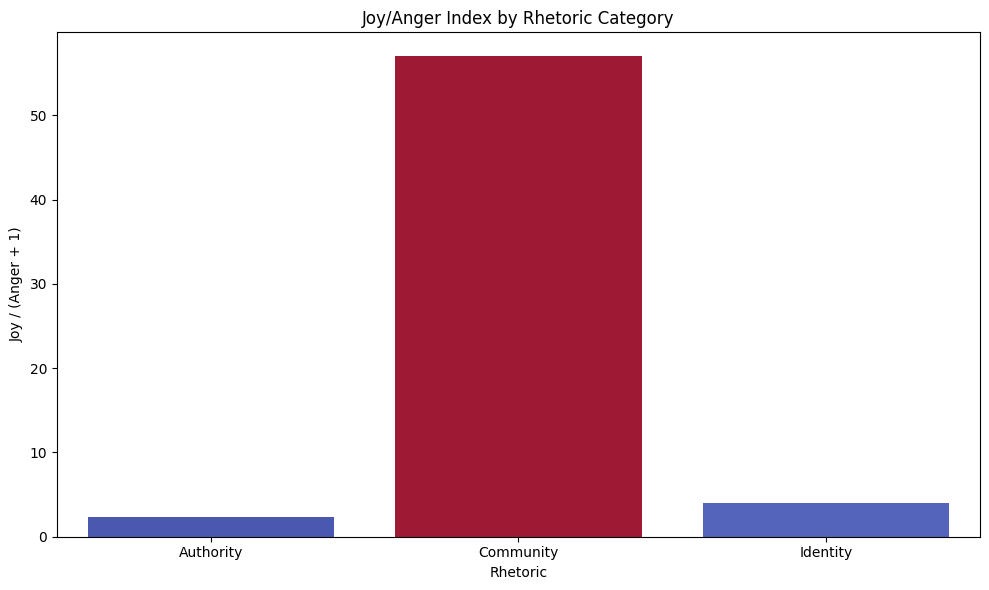

In [28]:
# Filter to only comments with joy or anger as top emotion
joy_anger_df = comments_df[comments_df["top_emotion"].isin(["joy", "anger"])]

# Count joy and anger per rhetoric
emotion_counts = joy_anger_df.groupby(["rhetoric", "top_emotion"]).size().unstack(fill_value=0)

# Calculate ratio
emotion_counts["joy_anger_ratio"] = emotion_counts["joy"] / (emotion_counts["anger"] + 1)  # add 1 to avoid division by 0

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=emotion_counts.index,
    y=emotion_counts["joy_anger_ratio"],
    hue=emotion_counts["joy_anger_ratio"],
    legend=False,
    palette="coolwarm"
)

plt.title("Joy/Anger Index by Rhetoric Category")
plt.xlabel("Rhetoric")
plt.ylabel("Joy / (Anger + 1)")
plt.tight_layout()
plt.show()

The results show that Community rhetoric is overwhelmingly positive, with a very high joy/anger ratio, while Identity rhetoric also leans toward joy but includes some anger. Authority rhetoric exhibits the lowest joy/anger ratio, indicating that discussions framed through Authority tend to be more emotionally charged and contentious.

In the next step we will filter the dataset for comments labeled as “joy” or “anger”, group them by rhetoric and emotion, and then sample 3 comments from each group. These will give you representative emotional expressions within each rhetorical category.

In [31]:
# Filter for joy and anger comments only
emotion_subset = comments_df[comments_df["top_emotion"].isin(["joy", "anger"])]

# Group by rhetoric and emotion, then sample
sampled_comments = (
    emotion_subset
    .groupby(["rhetoric", "top_emotion"])
    .apply(lambda df: df.sample(3, random_state=42) if len(df) >= 3 else df)
    .reset_index(drop=True)
)

# Display examples
for _, row in sampled_comments.iterrows():
    print(f"Rhetoric: {row['rhetoric']} | Emotion: {row['top_emotion']}")
    print(f"{row['body']}\n{'-'*80}")


Rhetoric: Authority | Emotion: anger
you're not actually supposed to interpret yin and yang you're supposed to acknowledge it.

if you interpret it, act on the interpretation, and the interpretation was an error, you have literally worked in direct opposition to the tao.
--------------------------------------------------------------------------------
Rhetoric: Authority | Emotion: anger
no probs :)
--------------------------------------------------------------------------------
Rhetoric: Authority | Emotion: anger
Targeting confucius.
--------------------------------------------------------------------------------
Rhetoric: Authority | Emotion: joy
Unless you, yourself, are the one who blindly believes an authority who states or implies they have had contact with the divine when it's only their subjective feelings and calling it godly, and then you foolishly believe them. 

Now who is delusional? 

And it's irrelevant whether one other person or millions believe this authority, because

C:\Users\bacep\AppData\Local\Temp\ipykernel_37376\2528390513.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.sample(3, random_state=42) if len(df) >= 3 else df)


In [36]:
# Save the full DataFrame with all annotations
comments_df.to_csv("../data/taoism_comments_labeled_with_sentiment_emotion.csv", index=False)
print("Dataset saved to '../data/taoism_comments_labeled_with_sentiment_emotion.csv'")

Dataset saved to '../data/taoism_comments_labeled_with_sentiment_emotion.csv'


To complement the quantitative joy/anger index, we sampled example comments from each rhetoric-emotion pair. The examples show clear patterns: Community joy comments are supportive and friendly, while Authority anger comments often reflect gatekeeping or critique. Identity comments show more mixed emotional tones, with both personal reflections and disagreements. These examples help contextualize the emotional dynamics observed earlier.